In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import cmocean.cm as cmo
import numpy as np
from scipy.stats import linregress
plt.rcParams.update({'font.size': 20})

import sys
sys.path.append("/home/jupyter-vincent2/vincent/process_profiles/noteboooks_2026/functions")
from create_rec_datasets import r_analysis_df

/home/jupyter-vincent2/.local/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/jupyter-vincent2/.local/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (
/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
### Bathy
ncfile_etopo1 = "/media/disk2/vincent/process_profiles/data/external_supports/GEBCO_ker_large.nc"
ds_topo = xr.open_dataset(ncfile_etopo1)
elevation = ds_topo.elevation[::10,::10]
### Fronts
ds_front = xr.open_dataset("/media/disk2/vincent/process_profiles/data/external_supports/62985.nc")

### Datasets
ds_CMA,df_CMA,df_XIEST_CMA,df_PHI_CMA,df_GRID_CMA,df_MU_CMA,df_lambda_CMA = r_analysis_df("CMA_masked")
ds_G,df_G,df_XIEST_G,df_PHI_G,df_GRID_G,df_MU_G,df_lambda_G = r_analysis_df("GLORYS_masked",dense=True)
ds_CL,df_CL,df_XIEST_CL,df_PHI_CL,df_GRID_CL,df_MU_CL,df_lambda_CL = r_analysis_df("GLORYS_CL_masked")

legend_fs = 15
G_color = "#0D160B"
CMA_color = "#008DD5"
CL_color = "#CB152B"

# Mask all variables that include both ("long", "lat") dimensions
# Keep only the selected box; outside becomes NaN
lon_min = 68.25
lon_max = 70.75
lat_min = -50
lat_max = -48

def apply_spatial_mask(ds, lon_min, lon_max, lat_min, lat_max):
    lon2d, lat2d = xr.broadcast(ds["long"], ds["lat"])
    area_mask = (
        (lon2d >= lon_min) & (lon2d <= lon_max) &
        (lat2d >= lat_min) & (lat2d <= lat_max)
    )

    ds_out = ds.copy()
    for v in ds_out.data_vars:
        if {"long", "lat"}.issubset(ds_out[v].dims):
            ds_out[v] = ds_out[v].where(~area_mask)
    return ds_out

ds_CMA = apply_spatial_mask(ds_CMA, lon_min, lon_max, lat_min, lat_max)
ds_G   = apply_spatial_mask(ds_G, lon_min, lon_max, lat_min, lat_max)
ds_CL  = apply_spatial_mask(ds_CL, lon_min, lon_max, lat_min, lat_max)

204
204
204


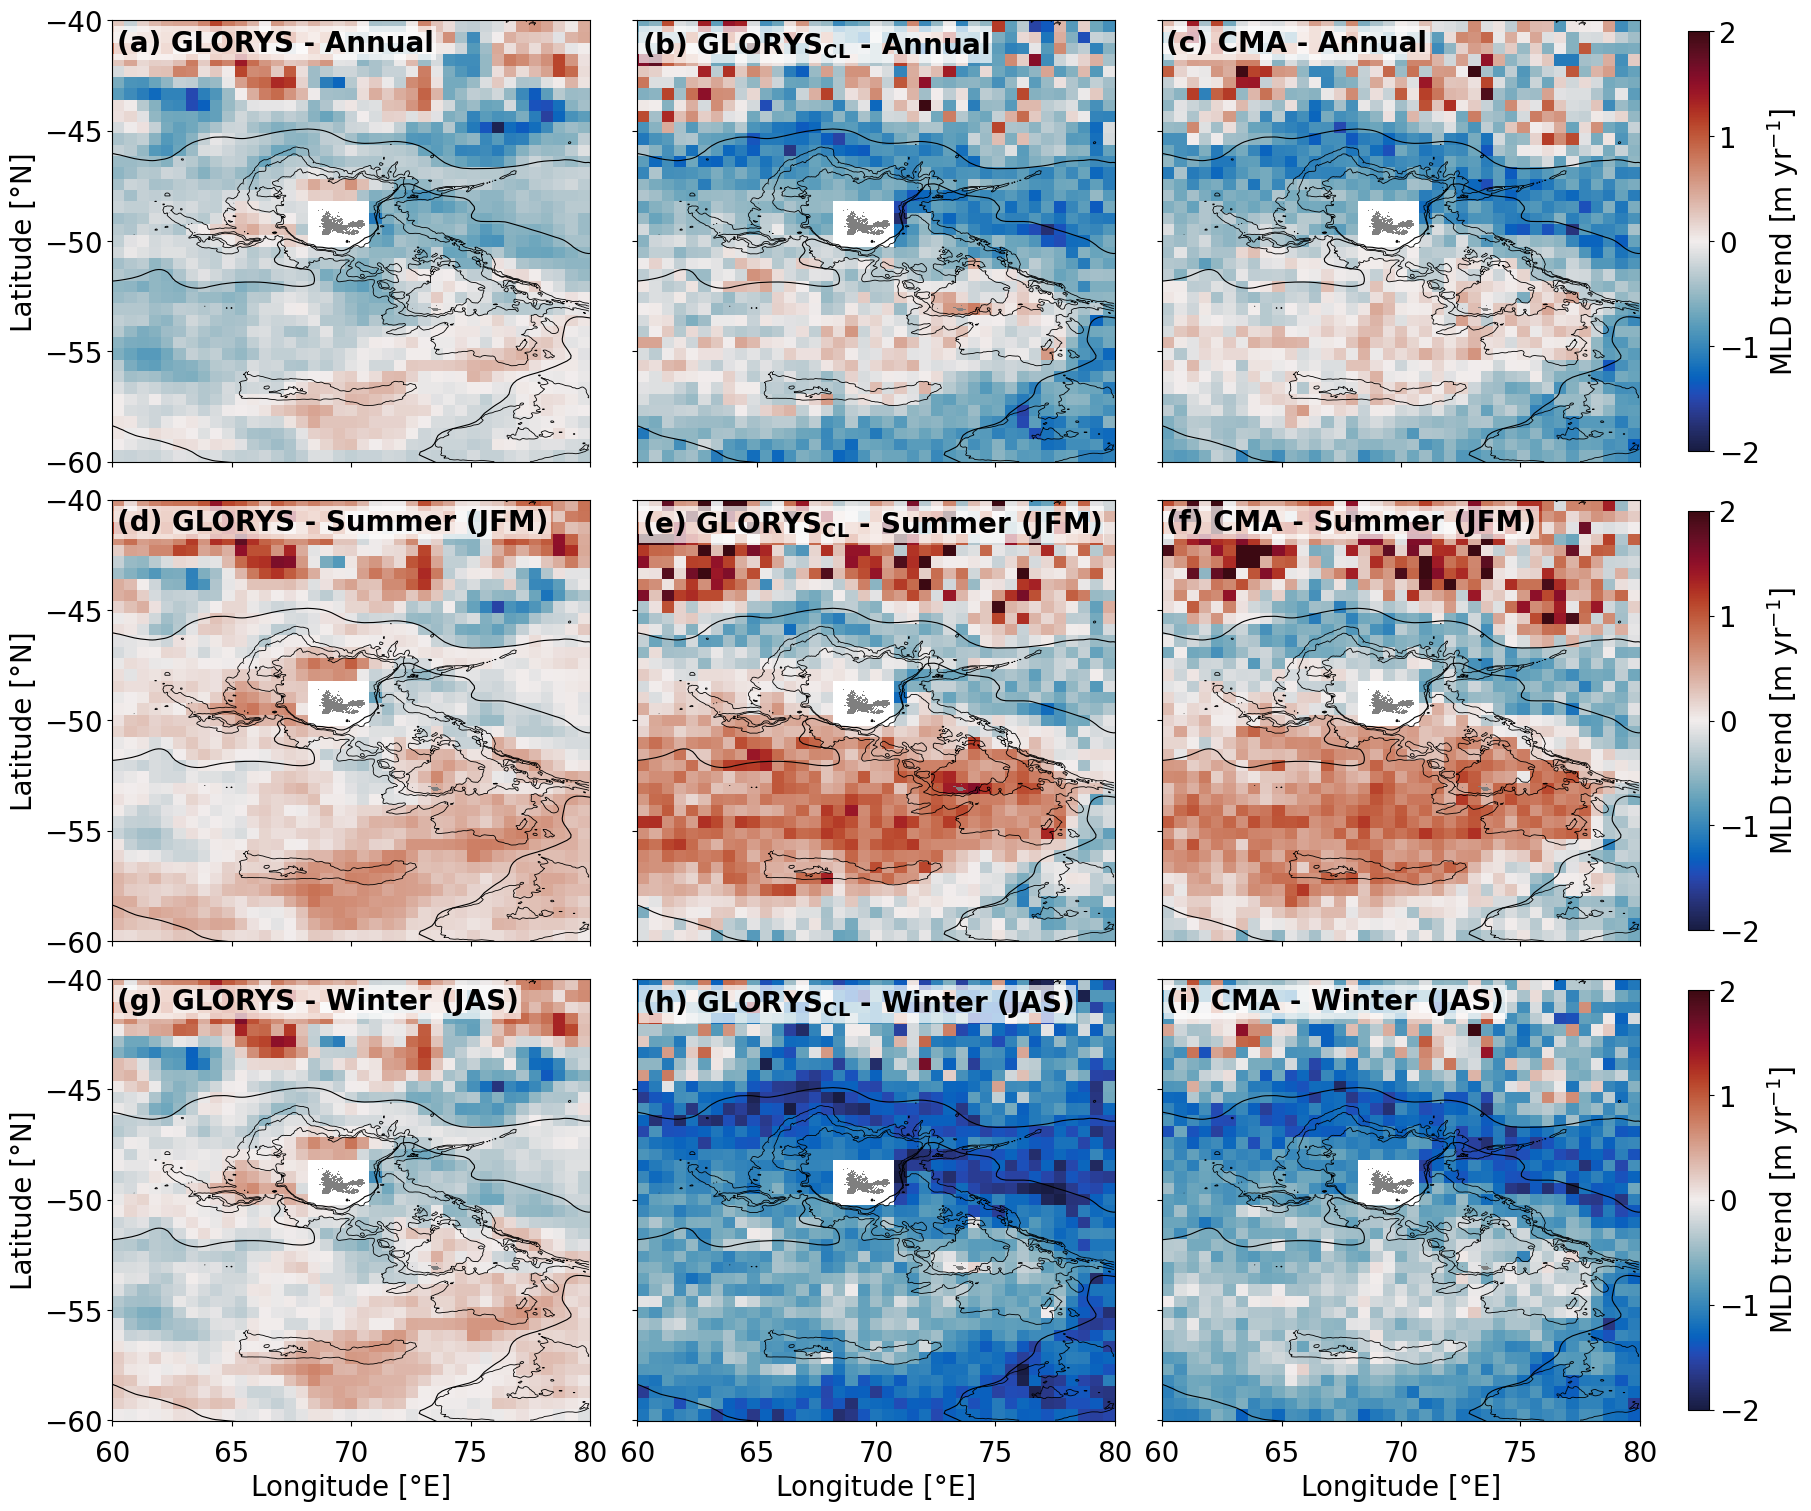

In [6]:
# Per-grid-cell seasonal MLD trends (m/year)
# Columns = datasets, rows = periods
ds_map = {
    "GLORYS": ds_G,
    "GLORYS_CL": ds_CL,
    "CMA": ds_CMA,
}

periods = {
    "Annual": list(range(1, 13)),
    "Summer (JFM)": [1, 2, 3],
    "Winter (JAS)": [7, 8, 9],
}

dataset_order = [k for k in ["GLORYS", "GLORYS_CL", "CMA"] if k in ds_map]


def seasonal_trend_map(ds_in, months, min_years=8):
    da = ds_in["mld"]  # (time, long, lat)
    sub = da.where(da["time"].dt.month.isin(months), drop=True)

    if set(months) == {12, 1, 2}:  # DJF case
        season_year = xr.where(
            sub["time"].dt.month == 12,
            sub["time"].dt.year + 1,
            sub["time"].dt.year,
        )
    else:
        season_year = sub["time"].dt.year

    season_year = season_year.rename("season_year")
    da_y = sub.groupby(season_year).mean("time", skipna=True)  # (season_year, long, lat)
    x = da_y["season_year"].astype(float)

    def _slope(y, x, min_points=8):
        m = np.isfinite(y) & np.isfinite(x)
        if m.sum() < min_points:
            return np.nan
        return np.polyfit(x[m], y[m], 1)[0]

    return xr.apply_ufunc(
        _slope,
        da_y,
        x,
        input_core_dims=[["season_year"], ["season_year"]],
        output_core_dims=[[]],
        vectorize=True,
        dask="allowed",
        kwargs={"min_points": min_years},
        output_dtypes=[float],
    )


def nice_cbar_scale(vabs):
    if not np.isfinite(vabs) or vabs == 0:
        return 1.0, np.arange(-1.0, 1.0 + 0.5, 0.5)

    step = 0.5 if vabs <= 1.5 else 1.0
    vabs_nice = np.ceil(vabs / step) * step
    ticks = np.arange(-vabs_nice, vabs_nice + step * 0.5, step)
    return vabs_nice, ticks


# Compute trend maps
trend_maps_period_dataset = {
    p_name: {d_name: seasonal_trend_map(ds_map[d_name], months) for d_name in dataset_order}
    for p_name, months in periods.items()
}

# Common color scale per row (per period)
vabs_per_period = {}
cbar_ticks_per_period = {}
for p_name in periods:
    all_vals = np.concatenate(
        [trend_maps_period_dataset[p_name][d].values.ravel() for d in dataset_order]
    )
    raw_vabs = np.nanpercentile(np.abs(all_vals), 98)
    vabs_nice, cbar_ticks = nice_cbar_scale(raw_vabs)
    vabs_per_period[p_name] = vabs_nice
    cbar_ticks_per_period[p_name] = cbar_ticks

# Plot: rows = periods, cols = datasets
fig, axes = plt.subplots(
    nrows=len(periods),
    ncols=len(dataset_order),
    figsize=(18, 15),
    sharex=True,
    sharey=True,
    constrained_layout=True,
    squeeze=False,
)

# Set uniform colorbar limits
vabs_uniform = 2.0
cbar_ticks_uniform = np.arange(-2.0, 2.5, 1)

for i, period_name in enumerate(periods.keys()):
    for j, d_name in enumerate(dataset_order):
        ax = axes[i, j]
        tr = trend_maps_period_dataset[period_name][d_name]

        im = ax.pcolormesh(
            tr["long"],
            tr["lat"],
            tr.transpose("lat", "long"),
            shading="auto",
            cmap=cmo.balance,
            vmin=-vabs_uniform,
            vmax=vabs_uniform,
        )

        (elevation / elevation).where(elevation > 0).plot(add_colorbar=False, cmap="gist_yarg", ax=ax)
        (-elevation).plot.contour(levels=(500, 1000, 2000), colors="k", linewidths=0.6, ax=ax)
        ax.plot(ds_front.LonSAF.where(ds_front.LatSAF > -50), ds_front.LatSAF.where(ds_front.LatSAF > -50), c="k", lw=0.8)
        ax.plot(ds_front.LonPF, ds_front.LatPF, c="k", lw=0.8)
        ax.plot(ds_front.LonSACCF, ds_front.LatSACCF, c="k", lw=0.8)

        ax.set_xticks([60, 65, 70, 75, 80])
        ax.set_yticks([-60, -55, -50, -45, -40])
        ax.set_xlabel("Longitude [°E]" if i == len(periods) - 1 else "")
        ax.set_ylabel("Latitude [°N]" if j == 0 else "")

    cbar = fig.colorbar(
        im,
        ax=axes[i, :],
        orientation="vertical",
        shrink=0.95,
        pad=0.02,
        ticks=cbar_ticks_uniform,
    )
    cbar.set_label("MLD trend [m yr$^{-1}$]")

for i, ax_i in enumerate(axes.ravel()):
    period_idx = i // len(dataset_order)
    dataset_idx = i % len(dataset_order)
    d_name = dataset_order[dataset_idx]
    label = "GLORYS$_{\\mathregular{CL}}$" if d_name == "GLORYS_CL" else d_name
    ax_i.text(
        0.01, 0.98, f"({chr(97 + i)}) {label} - {list(periods.keys())[period_idx]}",
        transform=ax_i.transAxes,
        ha="left", va="top",
        fontsize=20, fontweight="bold",
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=2),
    )

for ax_i in axes[-1, :]:  # Only bottom row
    ax_i.tick_params(axis="x", which="major", pad=10)


fig.savefig("/home/jupyter-vincent2/vincent/process_profiles/figures_2026/Figure_8_2D_trends.png",dpi=300, bbox_inches="tight")
